## Proyecto Presupuesto Obra

Este es un proyecto en que se aplicará un algoritmo de regresión lineal para determinar con base en la información racabada en un Excel el presupuesto de algunas Obras Civiles.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
from statsmodels.stats.outliers_influence import  variance_inflation_factor
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

In [2]:
#Configuración para planos profesionales
sns.set(style='whitegrid')

#Carga de datos
df = pd.read_csv('dataset_obras_civil_final.xls')

print("-----1.- Inspección Estructural del Archivo-----")
print(f'Total de Obras: {df.shape[0]}')
print(f'Total de Variable: {df.shape[1]}')

print("-----2.- Tipos de Datos -----")
#Se buscan los valores que tengan algún tipo de error
print(df.info())

print("-----3.- Estadística Descriptiva -----")
# .T transpone la tabla para leerla mejor
display(df.describe().T)

-----1.- Inspección Estructural del Archivo-----
Total de Obras: 3000
Total de Variable: 23
-----2.- Tipos de Datos -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Proyecto              3000 non-null   object 
 1   Tipo_Obra                3000 non-null   object 
 2   Entidad_Federativa       3000 non-null   object 
 3   Region                   2929 non-null   object 
 4   Fecha_Inicio             3000 non-null   object 
 5   Dia_Semana_Inicio        3000 non-null   object 
 6   Tipo_Terreno             3000 non-null   object 
 7   Tipo_Suelo               2557 non-null   object 
 8   Tipo_Licitacion          2652 non-null   object 
 9   Longitud_km              3000 non-null   float64
 10  Longitud_Yardas          3000 non-null   float64
 11  Area_m2                  3000 non-null   float64
 12  Distancia_

,count,mean,std,min,25%,50%,75%,max
Longitud_km,3000.0,7.678782,14.022460,0.00,0.0000,0.2955,9.34725,59.870
Longitud_Yardas,3000.0,8397.582937,15335.103725,0.00,0.0000,323.0885,10222.38125,65474.432
Area_m2,3000.0,90841.538663,214186.239046,0.00,1356.6375,5736.1950,17853.89000,1228712.760
Distancia_Banco_km,3000.0,61.489000,32.829445,5.00,34.0000,61.0000,90.00000,119.000
Volumen_Concreto_m3,2756.0,6857.216553,9374.527413,0.00,603.0775,2538.1700,10395.87000,49148.510
Peso_Acero_Ton,3000.0,548.460133,922.118228,0.00,0.0000,120.9500,702.37000,5461.530
Volumen_Excavacion_m3,3000.0,206889.187090,549655.905022,0.00,2443.9675,10260.5050,92743.65750,5529370.600
Volumen_Asfalto_m3,3000.0,14964.890147,38829.020261,0.00,0.0000,0.0000,0.00000,286942.040
Volumen_Relleno_m3,2746.0,9390.407932,22726.409258,-92341.62,0.0000,0.0000,0.00000,119853.360
Duracion_Estimada_Meses,3000.0,132.582067,273.347482,1.00,12.6000,35.0000,104.07500,3207.300


### Característica de los Datos

Hay varias columnas (Región,Tipo de Suelo,tipo delicitación,distancia tiro y volumen) que tienen valores nulos, las columnas de fechas no tienen el formato adecuado y la columna de Volumen de relleno tiene un minimo negativo.

### Limpieza de  Datos...
Con base en los detalles visto no podemos pasar los datos al algoritmo y generar el modelo, primero se debe asegurar que los datos estén en los formatos adecuados, que no haya nulos y los datos sean representativos. Para lograr lo anterior se han tomado las siguientes decisiones:

* Se convertira la columna de fecha de tipo objeto a datetime.
* Se asume que los valores negativos ingresados fueron errores de dedo y aplicaremos el valor absoluto.
* Imputación de valores nulos: En aquellas columnas en las que hay valores nulos estos se remplazaran ya sea con la  moda o la media dependiendo de si es variable categorica o númerica.


In [3]:
# Veamos cuántos valores nulos hay en el dataframe
print(f'Filas totales: {df.shape[0]}')
print(f'Nulos totales: {df.isnull().sum().sum()}')

# Correción de formato de Fechas
df['Fecha_Inicio'] = pd.to_datetime(df['Fecha_Inicio'],errors='coerce')

# Correción de valores negativos
n_neg = (df['Volumen_Relleno_m3']<0).sum()
df['Volumen_Relleno_m3'] = df['Volumen_Relleno_m3'].abs()
print(f'Se corrigieron {n_neg} valores negativos en {df['Volumen_Relleno_m3']}')

#Imputación de valores nulos
#Separamos las columnas por tipo
nums = df.select_dtypes(include=[np.number]).columns
cats = df.select_dtypes(include=['object']).columns

for col in nums:
    if df[col].isnull().sum() > 0 :
        mediana = df[col].median()
        df[col].fillna(mediana, inplace=True)
        print(f'{col} rellenada con mediana: {mediana}')

for col in cats:
    if df[col].isnull().sum()>0:
        # Puede haber varios elementos considerados como moda se toma el primer elemento [0]
        moda = df[col].mode()[0]
        df[col].fillna(moda, inplace=True)
        print(f'{col} rellenada con moda:{moda}')

print(f'Nulos restantes: {df.isnull().sum().sum()}')


Filas totales: 3000
Nulos totales: 2467
Se corrigieron 3 valores negativos en 0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
2995    0.0
2996    0.0
2997    0.0
2998    0.0
2999    NaN
Name: Volumen_Relleno_m3, Length: 3000, dtype: float64
Volumen_Concreto_m3 rellenada con mediana: 2538.17
Volumen_Relleno_m3 rellenada con mediana: 0.0
Region rellenada con moda:Centro
Tipo_Suelo rellenada con moda:Semiduro
Tipo_Licitacion rellenada con moda:Privada
Distancia_Tiro_km rellenada con moda:Sin Dato
Horas_Maquinaria rellenada con moda:Revisar
Costo_Directo_Total rellenada con moda:Por definir
Nulos restantes: 600


C:\Users\Carlos\AppData\Local\Temp\ipykernel_148\2690484592.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mediana, inplace=True)
C:\Users\Carlos\AppData\Local\Temp\ipykernel_148\2690484592.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when 

Ya hemos rreducido la cantidad de valores nulos pero aún quedan 600 en el dataset. Antes de tomar cualquier decisión es importante identificar dónde se alojan esos nulos antes de tomar cualquier decisión. Es muy probable que éstos estén en la columna de fecha ya que es la única que tiene un formato diferente de los que se contemplaron previamente.

In [4]:
#Paso 1 Obtener el número de nulos por columnas
nulos_columna = df.isnull().sum()

# Paso 2 Filtrar solo aquellos que tienen problemas
print(nulos_columna[nulos_columna>0].sort_values(ascending=False))

Fecha_Inicio    600
dtype: int64


A pesar de que la columna fecha_inicio se muestra como entero debe cambiarse a la que realmente le corresponde que es fecha. Una vez cambiado el formato la imputación a aplicar aquí es diferente de lo que se hizo en las columnas tipo object o int. 

En este caso, al ser una serie de tiempo la mejor práctica es rellenar huecos mediante Continuidad. Lo que significa que en registros sin valores se tomará el registro con valor más cercano y se asignará al nulo.

In [5]:
print(f'Nulos en fecha antes de reparar: {df['Fecha_Inicio'].isnull().sum()}')
#Asegurarse de que tengan el formato correcto
df['Fecha_Inicio'] = pd.to_datetime(df['Fecha_Inicio'], errors='coerce')

# Imputar por Continuidad
df['Fecha_Inicio'] = df['Fecha_Inicio'].ffill().bfill()

#Verificación
print(f'Nulos en Fecha después de imputación : {df['Fecha_Inicio'].isnull().sum()}')
print(f'Total de nulos en el Dataset: {df.isnull().sum().sum()}')

Nulos en fecha antes de reparar: 600
Nulos en Fecha después de imputación : 0
Total de nulos en el Dataset: 0


## Identificar Variables
Una vez que hemos limpiado los datos, el siguiente paso se convierte en buscar aquellas variables que tienen repercusión en nuestra variable objetivo. 
Para identificar esas posibles relaciones haré una matriz de Correlación

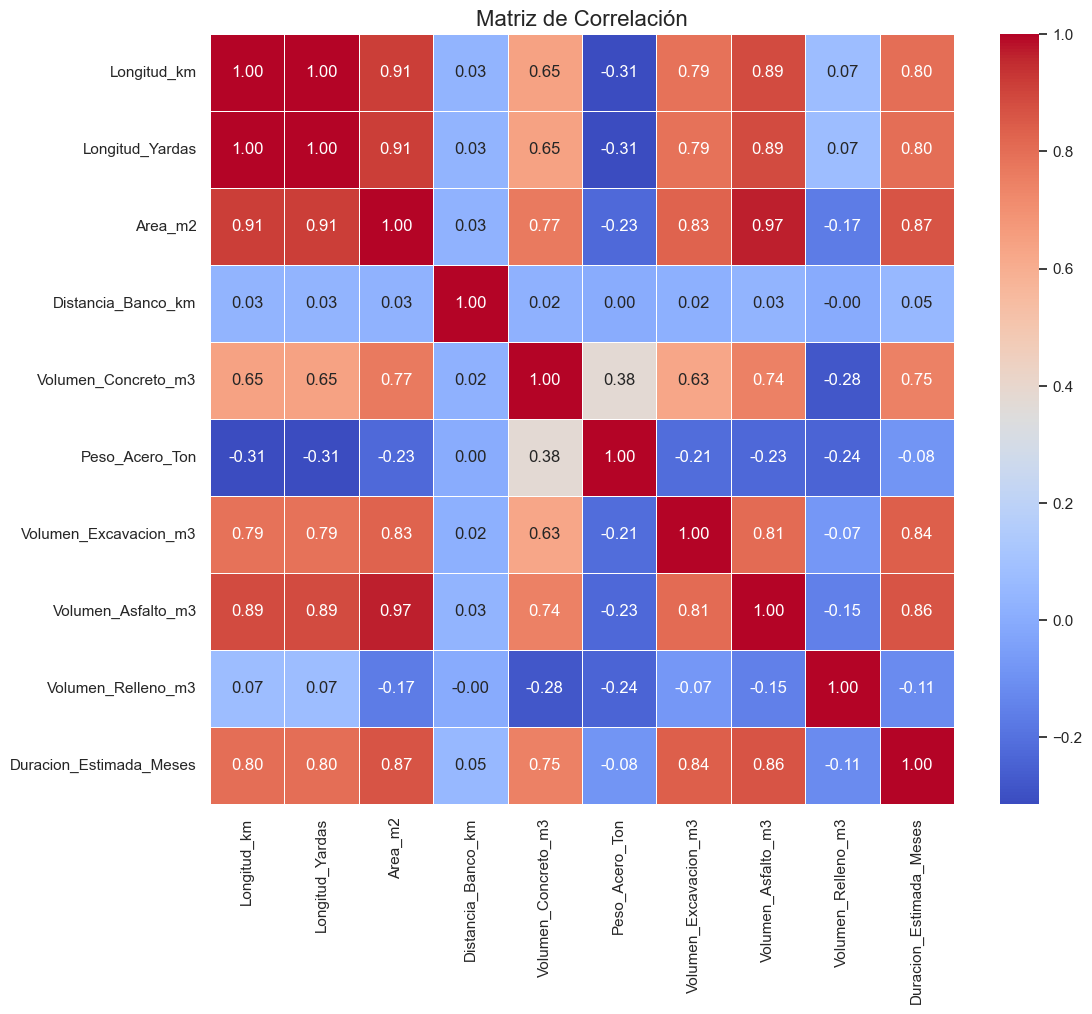

KeyError: 'Costo_Directo_Total'

In [6]:
#Configuración Visual
plt.figure(figsize=(12,10))
#Se fitran columnas sólo númericas
df_num =df.select_dtypes(include=[np.number])
matriz_corr = df_num.corr()

#Visualización la Matriz
#Annot= True muestra los nmúmeros dentro de l
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación', fontsize=16)
plt.show()

#Se genera una lista para ver las relaciones
print(matriz_corr['Costo_Directo_Total'].sort_values(ascending=False))

Como se puede ver la columna 'Costo_Directo_Total' ha sido interpretada como objeto en lugar de número, esto es posible ya que muy probablemente haya sido escrito de manera que sea interpretado como texto

Nuevo tipo de dato: float64


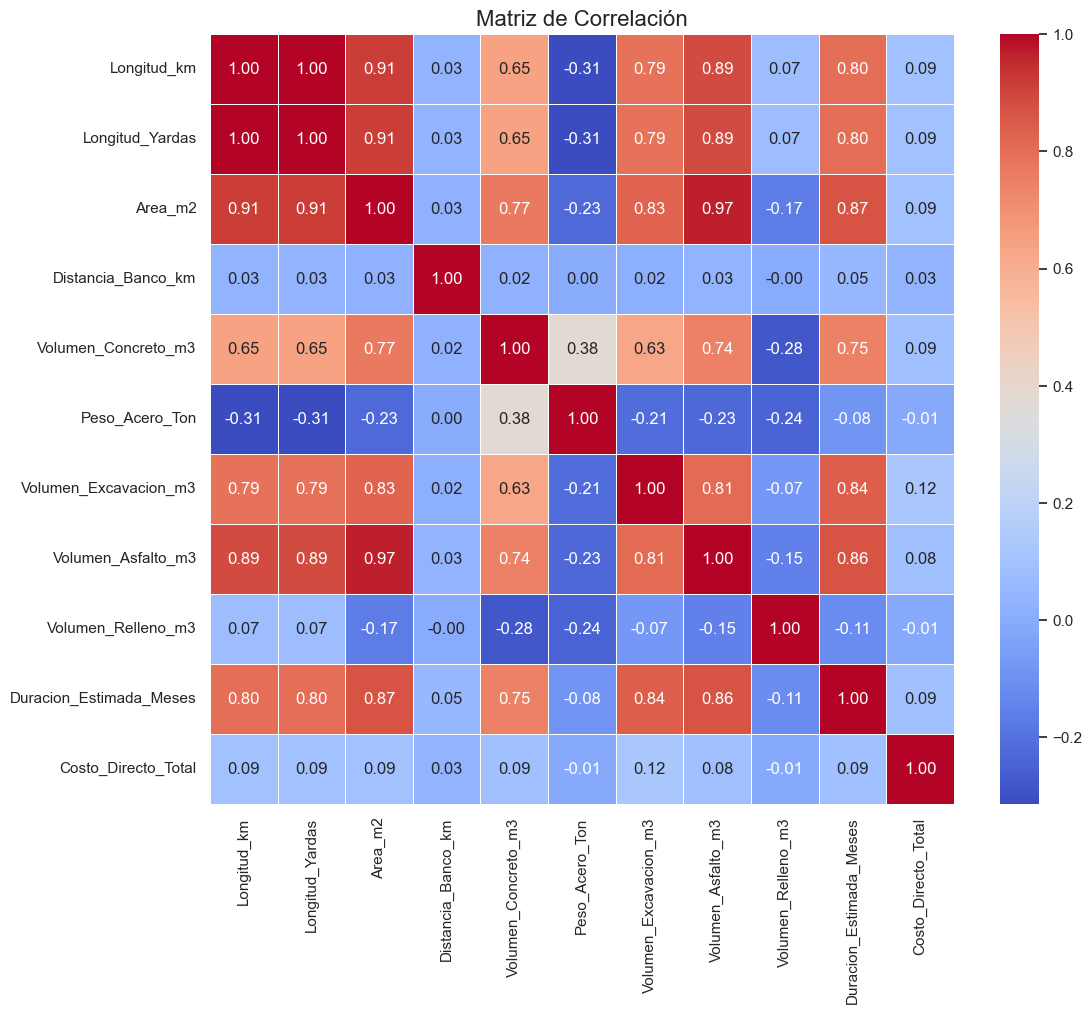

Costo_Directo_Total        1.000000
Volumen_Excavacion_m3      0.119717
Area_m2                    0.092973
Longitud_Yardas            0.092615
Longitud_km                0.092615
Duracion_Estimada_Meses    0.090836
Volumen_Concreto_m3        0.088600
Volumen_Asfalto_m3         0.081534
Distancia_Banco_km         0.033941
Peso_Acero_Ton            -0.006267
Volumen_Relleno_m3        -0.008485
Name: Costo_Directo_Total, dtype: float64


In [7]:
def convertir_texto_num(val):
    if pd.isna(val): return np.nan
    #Mantenemos sólo digitos y números
    clean = re.sub(r'[^\d.]','',str(val))
    try:
        return float(clean)
    except:
        return np.nan
    

# Se aplica la función a la columna
df['Costo_Directo_Total'] = df['Costo_Directo_Total'].apply(convertir_texto_num)

#Verificación
print(f'Nuevo tipo de dato: {df['Costo_Directo_Total'].dtype}')

# Generar correlación de nuevo
df_num= df.select_dtypes(include=[np.number])
plt.figure(figsize=(12,10))
matriz_corr = df_num.corr()
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm',linewidths=0.5)
plt.title('Matriz de Correlación', fontsize=16)
plt.show()
print(matriz_corr['Costo_Directo_Total'].sort_values(ascending=False))

### Cuidado

Al analizar la correlación que hay en las variables he podido notar que hay columnas que no aportan valor y que solo generan ruido, más adelante me encargaré de ellas. 

Aparentemente no hay relación con variables como volumen de concreto, peso de acero, etc. Pero eso es totalmente imposible sabemos por experiencia que estos son factores determinantes en el costo de la Obra, por lo que sabemos que hay datos que no son representativos, es decir que hay outliers.

Hay que identificar primero dónde están esos outliers para después manejarlos.

Analizando 10 Variables vs. Costo


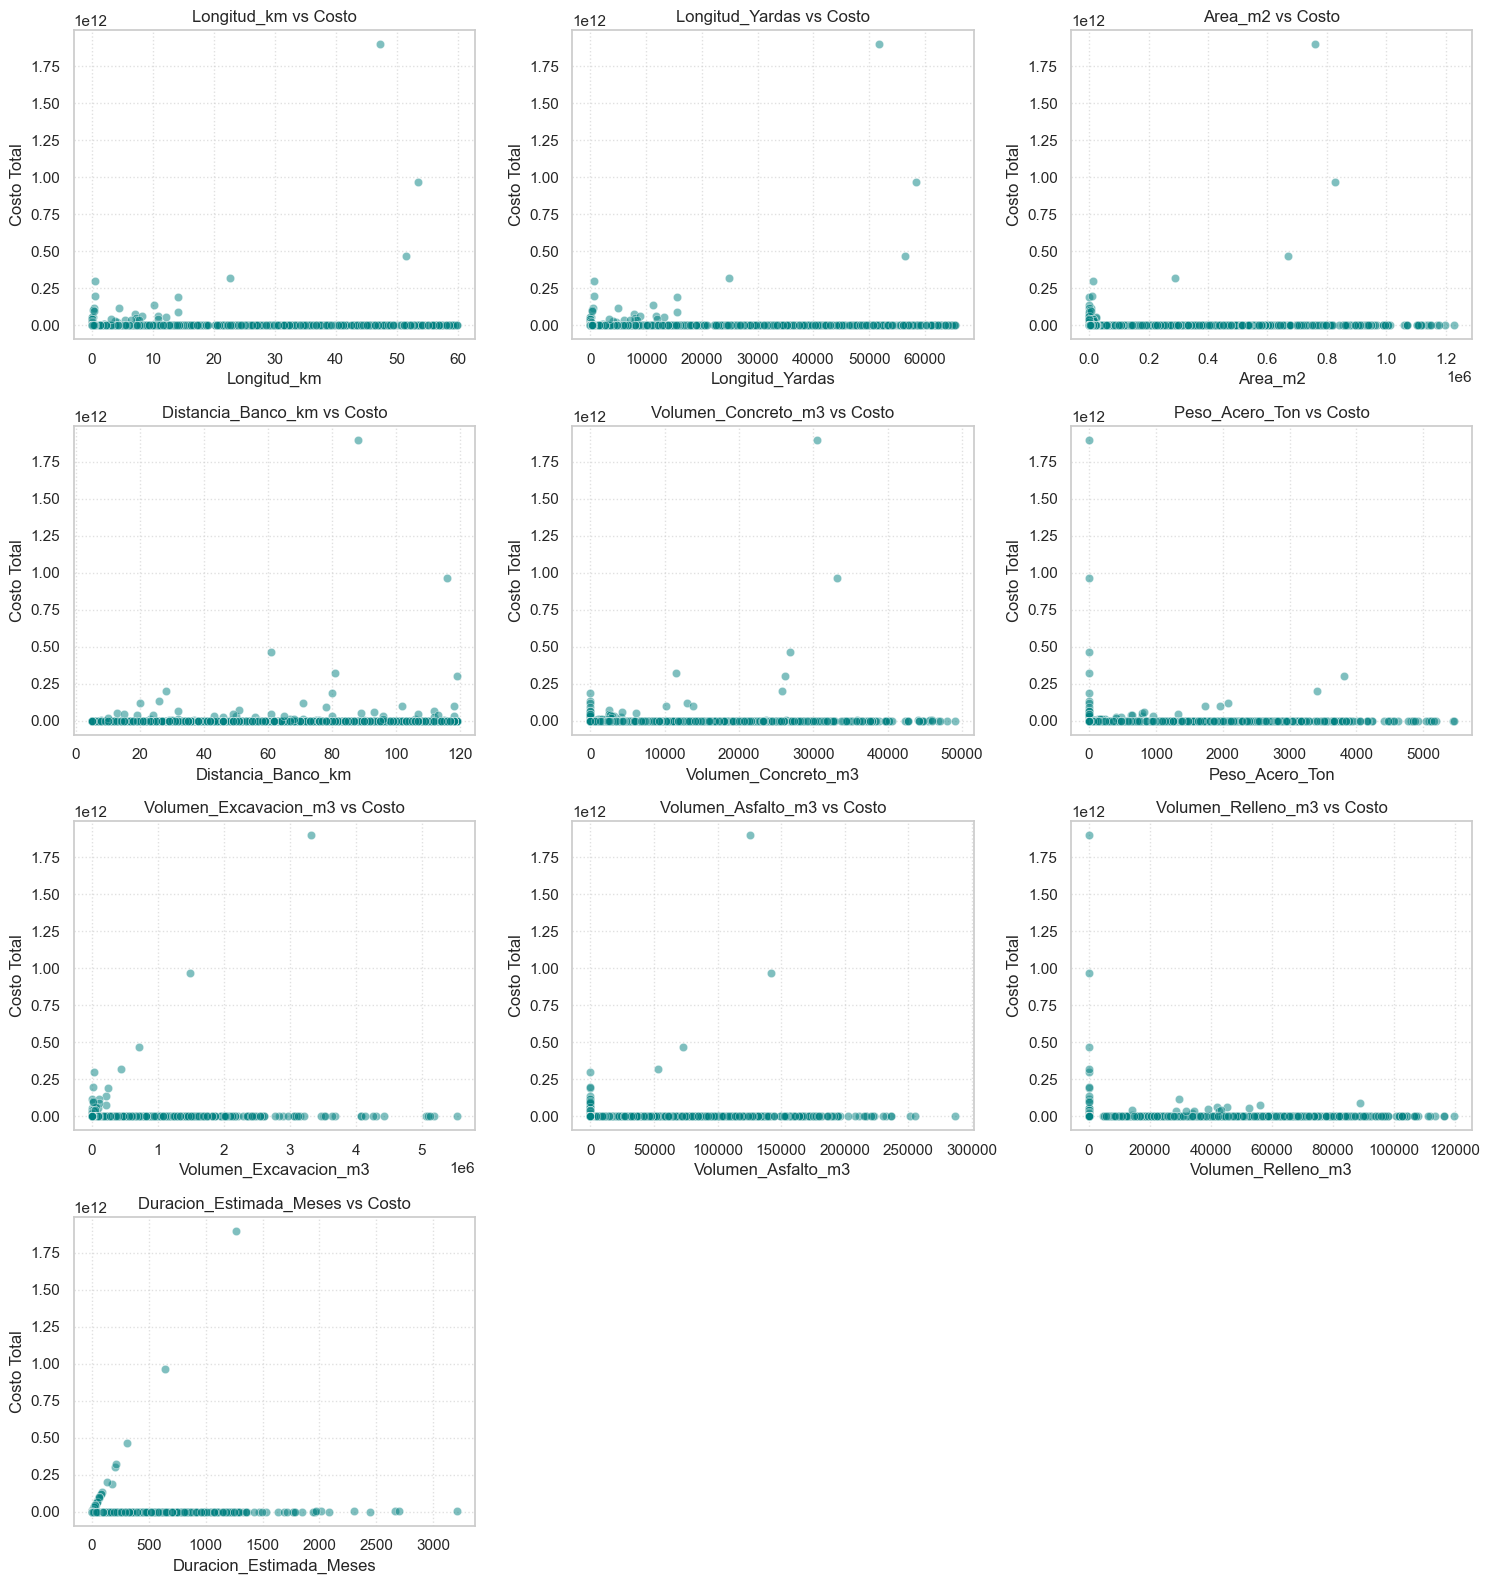

In [8]:
def plot_scatter_matrix(df, target_col):
    """
    Genera una matriz de gráficos de dispersión (Scatter Plots) para todas
    las variables numéricas contra una columna objetivo.
    
    Args:
        df (pd.DataFrame): El dataset a analizar.
        target_col (str): El nombre de la columna 'Y' (Objetivo/Costo).
    """
    #Seleccionar variables númericas
    cols_num = df.select_dtypes(include=[np.number]).columns.tolist()

    #Quitamos el costo por que será nuestro objetivo
    if 'Costo_Directo_Total' in cols_num:
        cols_num.remove('Costo_Directo_Total')

    #Configuración dinamica de la cuadricula de graficas
    n_vars = len(cols_num)
    n_cols = 3 #Número de graficas por fila
    n_rows = math.ceil(n_vars/n_cols)

    plt.figure(figsize=(15,4 * n_rows))
    print(f'Analizando {n_vars} Variables vs. Costo')

    #Generar gráficas
    for i, col in enumerate(cols_num):
        plt.subplot(n_rows, n_cols, i+1)
        #Grafica X vs Y
        sns.scatterplot(x=df[col], y=df['Costo_Directo_Total'], alpha=0.5,color='teal')
        plt.title(f'{col} vs Costo')
        plt.ylabel('Costo Total')
        plt.xlabel(col)
        plt.grid(True,linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()


plot_scatter_matrix(df, 'Costo_Directo_Total')

### Resultado
Después de haber revisado los scatter plots se nota un patrón denominado como cohete. Ese patron se ve como los datos están "pegados" al eje horizontal, y unos cuantos valores dispersos, esos valores son los outliers. La generación de estos outliers está en la columna "Costo_Directo_Total", es por eso que se da el patrón antes descrito.

Para tratar estos outliers se debe tomar el rango Intercuartil (IQR) de la columna "Costo_Directo_Total" para deshacerse de esos outliers y encontrar las relaciones


Limite de Corte detectado: 1245995202.33
Registros eliminados: 613
Registros finales: 2387
Analizando 10 Variables vs. Costo


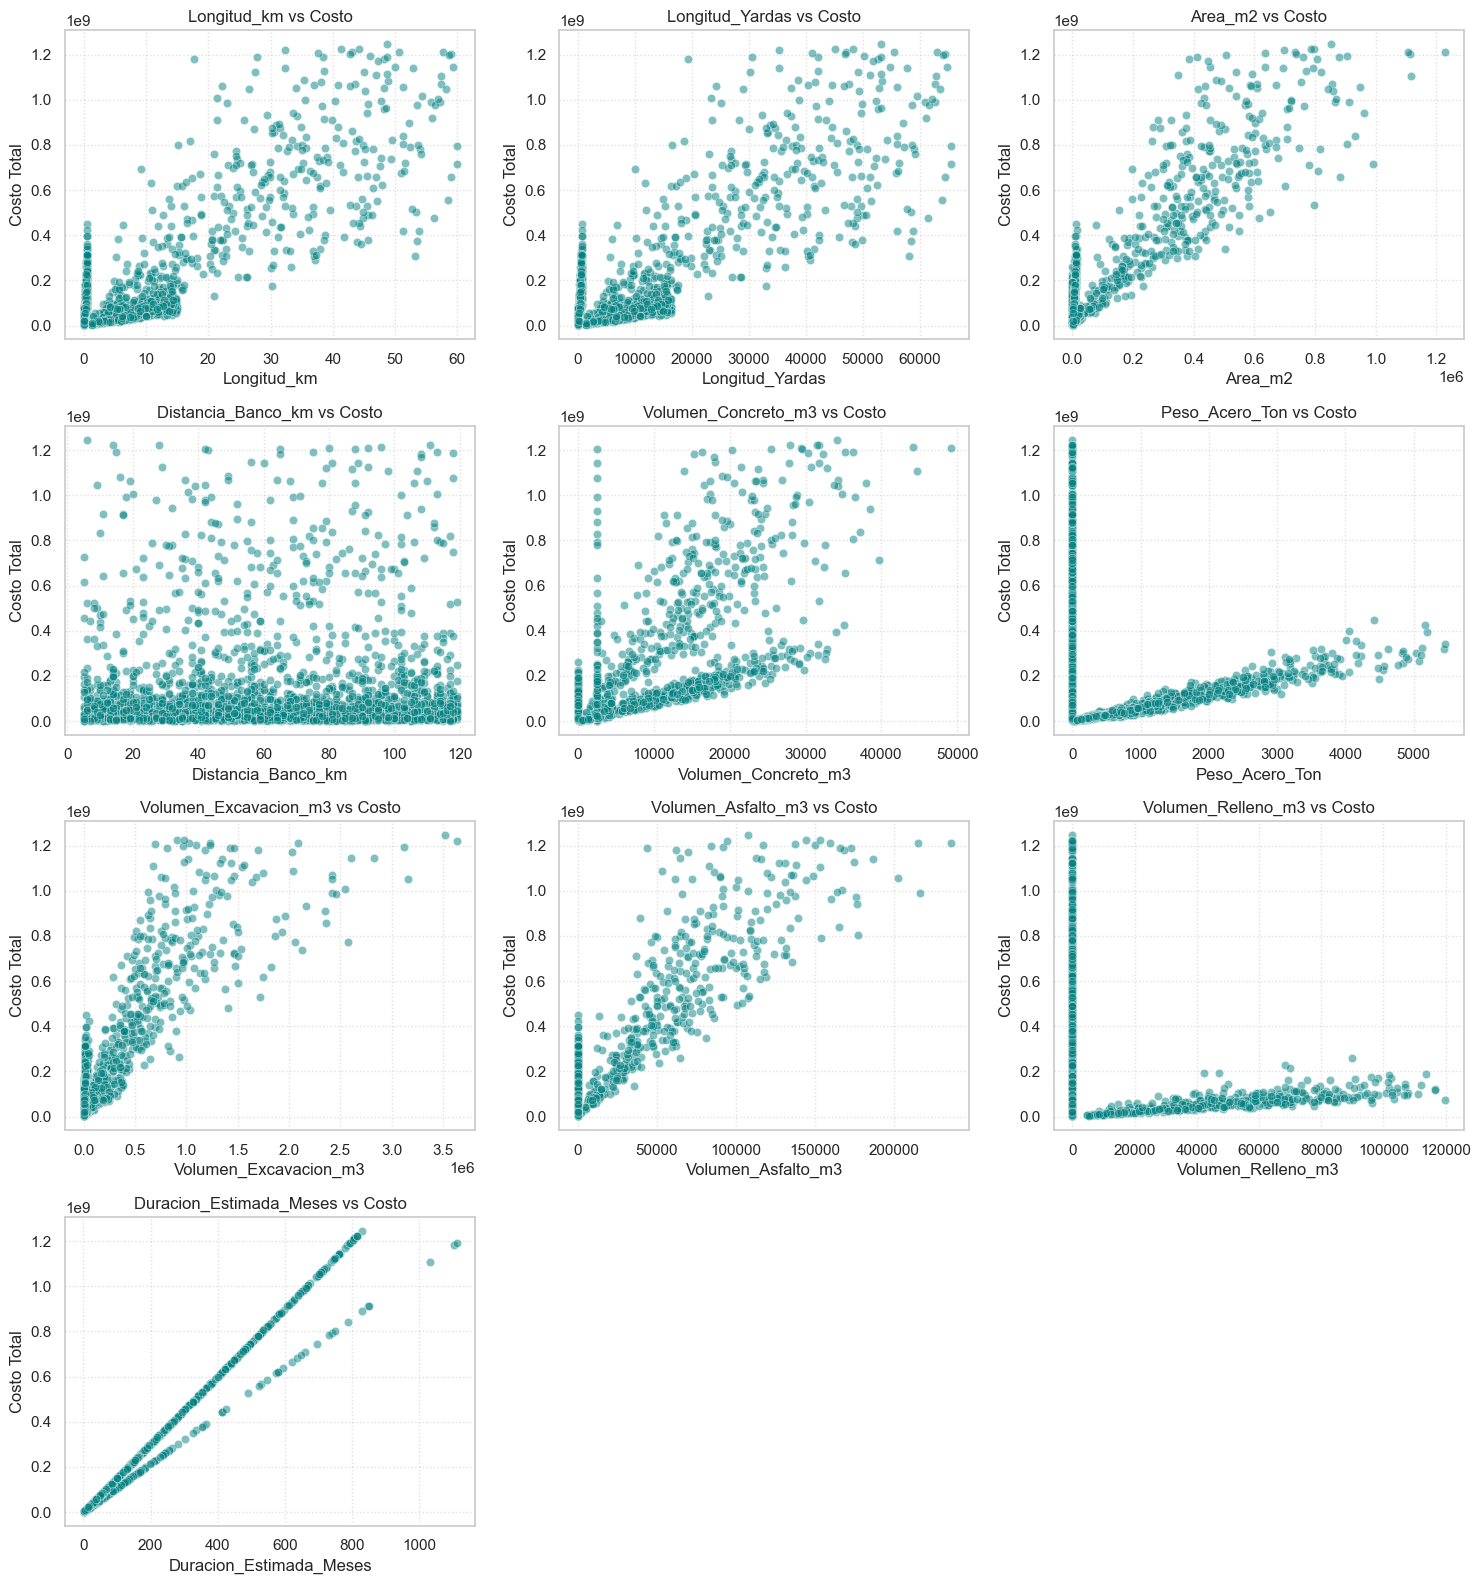

In [9]:
#Se tomará outlier todo valor superior a 95%
limite_superior = df['Costo_Directo_Total'].quantile(0.95)
print(f'Limite de Corte detectado: {limite_superior:.2f}')

#Filtrado
df_master = df[df['Costo_Directo_Total']<limite_superior].copy()
print(f'Registros eliminados: {df.shape[0]-df_master.shape[0]}')
print(f'Registros finales: {df_master.shape[0]}')

plot_scatter_matrix(df_master, 'Costo_Directo_Total')

Una vez modificados los outliers volvemos a buscar las relaciones esntre variables

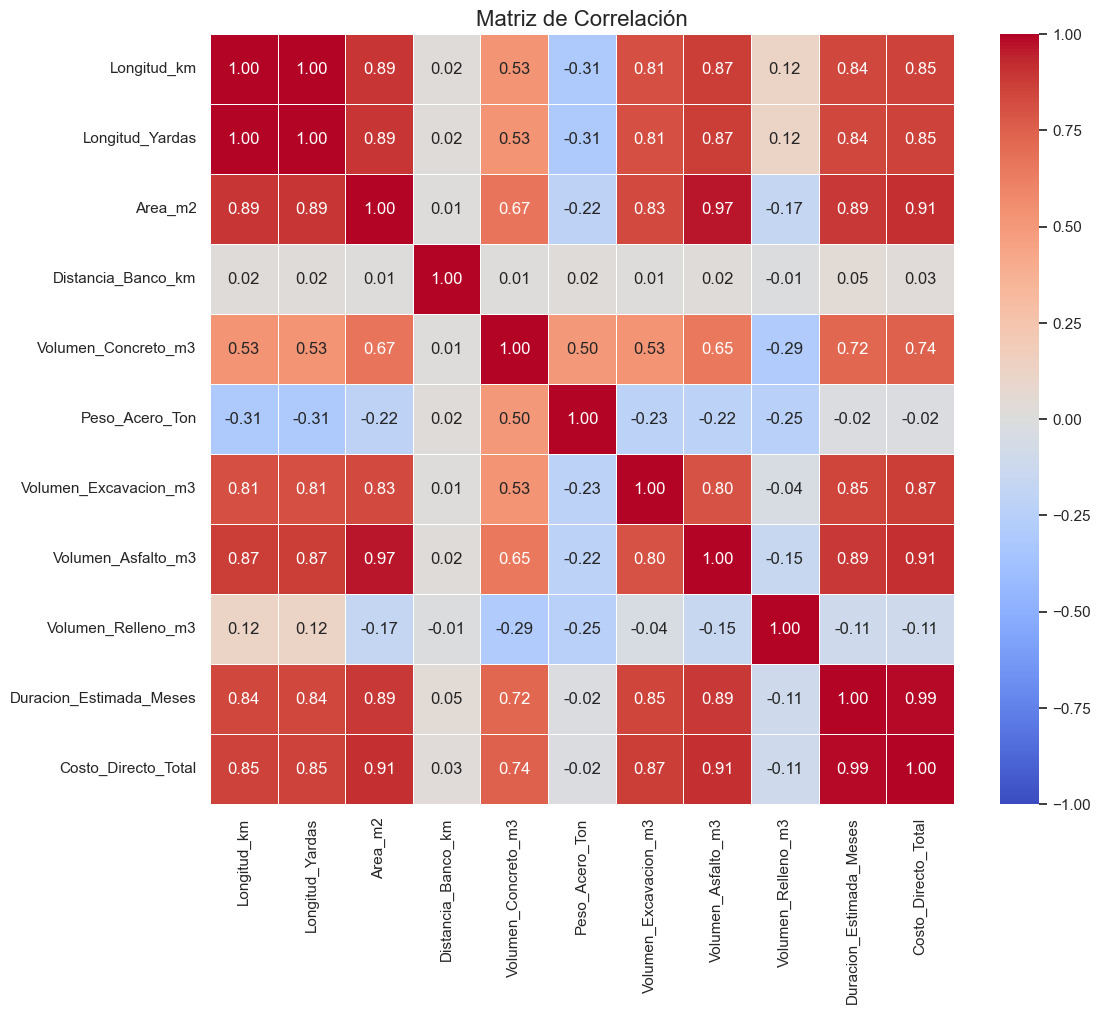

Costo_Directo_Total        1.000000
Duracion_Estimada_Meses    0.990868
Area_m2                    0.912444
Volumen_Asfalto_m3         0.909969
Volumen_Excavacion_m3      0.870569
Longitud_km                0.853772
Longitud_Yardas            0.853771
Volumen_Concreto_m3        0.742229
Distancia_Banco_km         0.028794
Peso_Acero_Ton            -0.020845
Volumen_Relleno_m3        -0.108530
Name: Costo_Directo_Total, dtype: float64


In [10]:
def plot_correlation_matrix(df, title='Matriz de Correlación'):
    """
    Calcula y visualiza la matriz de correlación de Pearson para 
    todas las variables numéricas del DataFrame.
    
    Args:
        df (pd.DataFrame): Dataset a analizar.
        title (str): Título del gráfico.
    """
    #Selección de variables matematicas
    df_num = df.select_dtypes(include=[np.number])
    matriz_corr = df_num.corr()
    plt.figure(figsize=(12,10))
    sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5,vmin=-1,vmax=1)
    plt.title(title, fontsize=16)
    plt.show()
    print(matriz_corr['Costo_Directo_Total'].sort_values(ascending=False))

plot_correlation_matrix(df_master)

In [ ]:
df_master.columns

Index(['ID_Proyecto', 'Tipo_Obra', 'Entidad_Federativa', 'Region',
       'Fecha_Inicio', 'Dia_Semana_Inicio', 'Tipo_Terreno', 'Tipo_Suelo',
       'Tipo_Licitacion', 'Longitud_km', 'Longitud_Yardas', 'Area_m2',
       'Distancia_Banco_km', 'Distancia_Tiro_km', 'Color_Senaletica',
       'Volumen_Concreto_m3', 'Peso_Acero_Ton', 'Volumen_Excavacion_m3',
       'Volumen_Asfalto_m3', 'Volumen_Relleno_m3', 'Horas_Maquinaria',
       'Duracion_Estimada_Meses', 'Costo_Directo_Total'],
      dtype='object')

### Limpieza Variables Categoricas

Una vez terminada la limpieza de las columnas númericas es turno de las categoricas

In [11]:
# Seleccionamos solo la columna de texto
cols_texto = df_master.select_dtypes(include=['object']).columns

for col in cols_texto:
    if col not in ['ID_Proyecto','Fecha_Inicio']:
        print(f'\n Variable: {col}')
        # Ver valores únicos ordenados alfabeticamente
        unicos = sorted(df[col].unique().astype(str))
        print(f'Valores distintos encontrados: {len(unicos)}')
        print(unicos)

        # Verificar la frecuencia
        print(df[col].value_counts())


 Variable: Tipo_Obra
Valores distintos encontrados: 5
['Carretera', 'Drenaje', 'Edificacion', 'Nave Industrial', 'Puente']
Tipo_Obra
Puente             617
Nave Industrial    616
Drenaje            608
Edificacion        582
Carretera          577
Name: count, dtype: int64

 Variable: Entidad_Federativa
Valores distintos encontrados: 16
['Baja California', 'CDMX', 'Chiapas', 'Chihuahua', 'EdoMex', 'Guanajuato', 'Hidalgo', 'Jalisco', 'Nuevo Leon', 'Oaxaca', 'Puebla', 'Queretaro', 'San Luis Potosi', 'Sonora', 'Tabasco', 'Veracruz']
Entidad_Federativa
CDMX               312
Puebla             299
Hidalgo            297
EdoMex             292
Nuevo Leon         252
Sonora             237
Chihuahua          202
Baja California    194
Oaxaca             124
Tabasco            123
Chiapas            123
Veracruz           116
Guanajuato         112
Jalisco            111
Queretaro          109
San Luis Potosi     97
Name: count, dtype: int64

 Variable: Region
Valores distintos encontrados: 

## Valores repetidos

Antes de continuar con las variables categoricas, es menester atender las siguiente situaciones que se debieron de haber visto desde el principio del Análisis. En el caso de las siguientes columnas: 

* Distancia_Tiro_Km
* Horas_Maquinaria

Están siendo interpretadas como variables categoricas cuando deberían ser númericas, por lo que se tienen que hacer esa modificación.


En la única columna en la que hay duplicado es en Tipo_Terreno:
* Plano         1371
* Ondulado       824
* Montañoso      505
* Plano          156
* Ondulado       105
* Montañoso       39

In [12]:
cols_numericas_sucias= ['Distancia_Tiro_km','Horas_Maquinaria']

for col in cols_numericas_sucias:
    if col in df_master.columns:
        df_master[col] = pd.to_numeric(df_master[col], errors='coerce')
        print(f'{col} ahora es tipo: {df_master[col].dtype}')

df['Tipo_Terreno'] = df['Tipo_Terreno'].replace({'Montañoso ':'Montañoso'})
df['Tipo_Terreno'] = df['Tipo_Terreno'].replace({'Ondulado ':'Ondulado'})
df['Tipo_Terreno'] = df['Tipo_Terreno'].replace({'Plano ':'Plano'})

df['Tipo_Terreno'].value_counts()

Distancia_Tiro_km ahora es tipo: float64
Horas_Maquinaria ahora es tipo: float64


Tipo_Terreno
Plano        1527
Ondulado      929
Montañoso     544
Name: count, dtype: int64

Una vez recuperada las columnas en el formato que deben tener es importante que no haya valores nulos y que no haya outliers en ellas.

       Distancia_Tiro_km  Horas_Maquinaria
count        2056.000000       1988.000000
mean           25.996595      12031.384085
std            13.674082      21906.432116
min             2.000000         24.230000
25%            15.000000        378.667500
50%            26.000000       3648.315000
75%            38.000000      11935.572500
max            49.000000     174044.090000


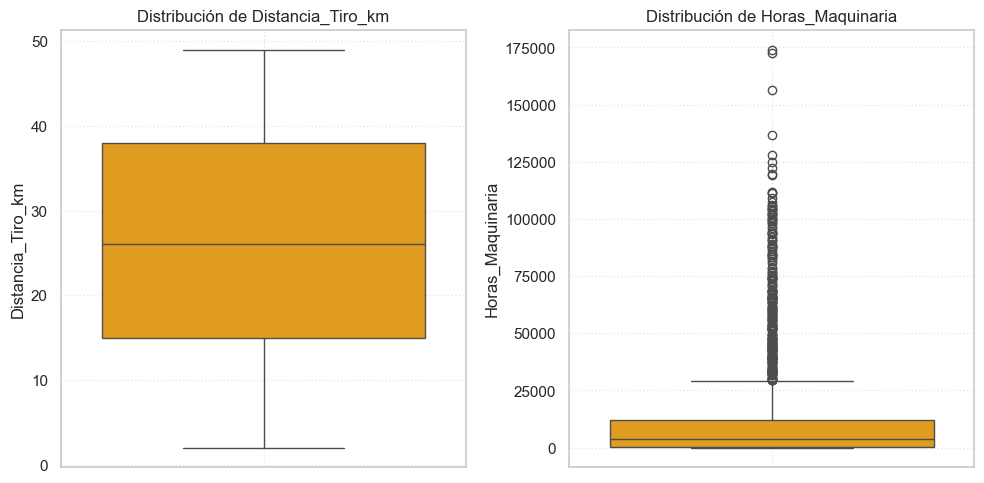

In [13]:
print(df_master[cols_numericas_sucias].describe())

#Visualización
plt.figure(figsize=(10,5))
for i, col in enumerate(cols_numericas_sucias):
    plt.subplot(1,2,i+1)
    sns.boxplot(y=df_master[col], color='orange')
    plt.title(f'Distribución de {col}')
    plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

Los valores de Distancia_Tiro_km estan bien, por el contrario hay outliers que limpiar en Horas_Maquinaria

Se encontraron: 20 registros de Horas al limite de 103593hrs.
Distancia_Tiro_km        49.0000
Horas_Maquinaria     103593.4584
dtype: float64


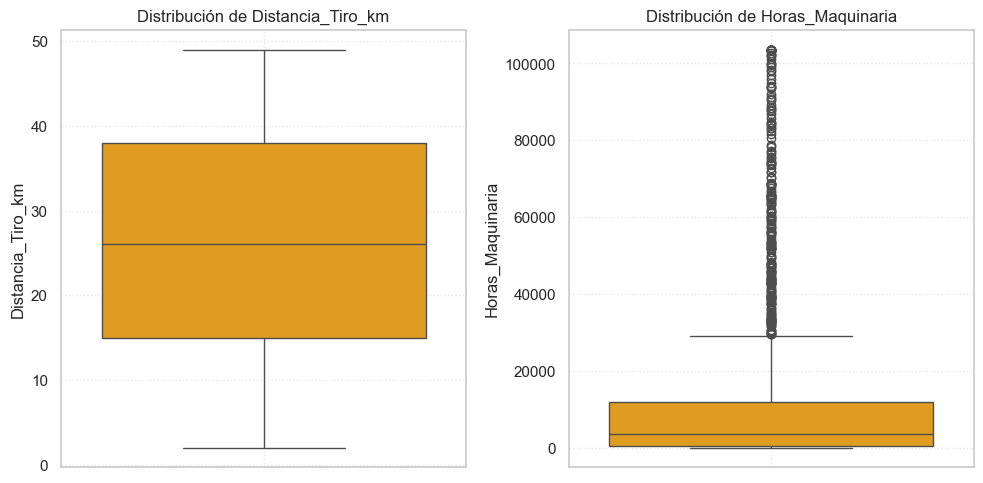

In [14]:
#Correción Horas Maquinaria (Tope Lógico: Percentil 99)
tope_horas = df_master['Horas_Maquinaria'].quantile(0.99)
filtro_horas =df_master['Horas_Maquinaria']>tope_horas
n_afectados = filtro_horas.sum()

if n_afectados > 0:
    print(f'Se encontraron: {n_afectados} registros de Horas al limite de {tope_horas:.0f}hrs.')
    df_master.loc[filtro_horas,'Horas_Maquinaria'] = tope_horas

# Verificación
print(df_master[cols_numericas_sucias].max())

plt.figure(figsize=(10,5))
for i, col in enumerate(cols_numericas_sucias):
    plt.subplot(1,2,i+1)
    sns.boxplot(y=df_master[col], color='orange')
    plt.title(f'Distribución de {col}')
    plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

Como se puede observar a pesar de seguir "cortando" Outliers siguen "apareciendo" esto puede ser correcto o no. Lo podemos saber basandonos en el tipo de obra que es y el tipo de actividades que se desarrollan en cada una de ellas.

Para saber si estos son realmente Outliers o no lo que se hará es volver a graficar los datos y ver su comportamiento, además se analizará la correlación entre las diferentes actividades y las horas de uso de maquinaria, si hay correlación significa que no son Outliers.

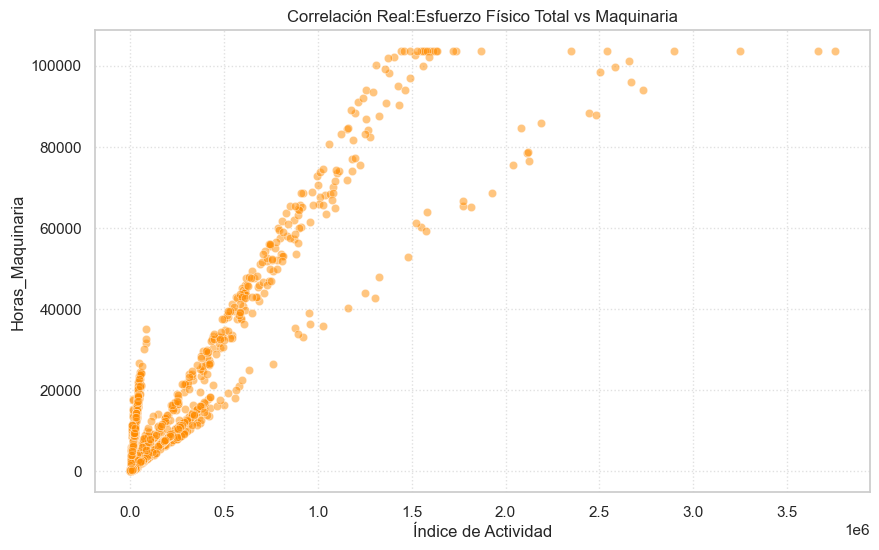

Correlación Matemaática (Actividad vs Maquinaria)_ 0.9221


In [15]:
# Se crea una variable en la que se contengan todos los tipos de actividades que requieran maquinaria
df_master['Indice_Actividad_Fisica'] = (df_master['Volumen_Asfalto_m3']+df_master['Volumen_Concreto_m3']+df_master['Volumen_Excavacion_m3']+(df_master['Volumen_Relleno_m3']*2))

# Total vs Horas
plt.figure(figsize=(10,6))
sns.scatterplot(x=df_master['Indice_Actividad_Fisica'],y=df_master['Horas_Maquinaria'],alpha=0.5,color='darkorange')
plt.title('Correlación Real:Esfuerzo Físico Total vs Maquinaria')
plt.xlabel('Índice de Actividad')
plt.grid(True, linestyle=':',alpha=0.6)
plt.show()

#Verifiación de correlación Matemática
corr_maq = df_master['Indice_Actividad_Fisica'].corr(df_master['Horas_Maquinaria'])
print(f'Correlación Matemaática (Actividad vs Maquinaria)_ {corr_maq:.4f}')

In [16]:
cols_problema = ['Distancia_Tiro_km', 'Horas_Maquinaria']

for col in cols_problema:
    valor_relleno = df_master[col].median()
    df_master[col].fillna(valor_relleno, inplace=True)
    print(f"{col}: Rellenados {col} nulos con la Mediana ({valor_relleno:.1f})")

df_master.isnull().sum()

Distancia_Tiro_km: Rellenados Distancia_Tiro_km nulos con la Mediana (26.0)
Horas_Maquinaria: Rellenados Horas_Maquinaria nulos con la Mediana (3648.3)


C:\Users\Carlos\AppData\Local\Temp\ipykernel_148\2391688200.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_master[col].fillna(valor_relleno, inplace=True)
C:\Users\Carlos\AppData\Local\Temp\ipykernel_148\2391688200.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

ID_Proyecto                0
Tipo_Obra                  0
Entidad_Federativa         0
Region                     0
Fecha_Inicio               0
Dia_Semana_Inicio          0
Tipo_Terreno               0
Tipo_Suelo                 0
Tipo_Licitacion            0
Longitud_km                0
Longitud_Yardas            0
Area_m2                    0
Distancia_Banco_km         0
Distancia_Tiro_km          0
Color_Senaletica           0
Volumen_Concreto_m3        0
Peso_Acero_Ton             0
Volumen_Excavacion_m3      0
Volumen_Asfalto_m3         0
Volumen_Relleno_m3         0
Horas_Maquinaria           0
Duracion_Estimada_Meses    0
Costo_Directo_Total        0
Indice_Actividad_Fisica    0
dtype: int64

### Encoding

La limpieza del data set se ha completado, ahora debemos preparar los datos para que el algoritmo pueda leerlo, se hará 3 cosas:

* Separar de la columna fecha año y mes
* Convertir datos categoricos a nuevas columnas  
* Eliminar la columna de fecha e ID ya que no contienen información relevante

In [17]:
df_encoding = df_master.copy()
print(f'Dimensiones antes de traducir: {df_encoding.shape}')

df_encoding['Fecha_Inicio'] = pd.to_datetime(df_encoding['Fecha_Inicio'])
#Extraemos lo númerico
df_encoding['Año_Inicio'] = df_encoding['Fecha_Inicio'].dt.year
df_encoding['Mes_Inicio']= df_encoding['Fecha_Inicio'].dt.month

df_encoding.drop(columns=['Fecha_Inicio','ID_Proyecto'], inplace=True)
print('Fechas convertidas a Año/Mes')

#One-Hot Encoding
# Detectar columnas que contienen texto
cols_texto = df_encoding.select_dtypes(include=['object']).columns
print(f'Variables de texto detectadas: {list(cols_texto)}')
#Convertimos texto a columnas de 1s y 0s
df_ml = pd.get_dummies(df_encoding, columns=cols_texto, drop_first=True)

#Verificación
print(f'Nuevas dimensiones: {df_ml.shape}')

Dimensiones antes de traducir: (2387, 24)
Fechas convertidas a Año/Mes
Variables de texto detectadas: ['Tipo_Obra', 'Entidad_Federativa', 'Region', 'Dia_Semana_Inicio', 'Tipo_Terreno', 'Tipo_Suelo', 'Tipo_Licitacion', 'Color_Senaletica']
Nuevas dimensiones: (2387, 55)


### ESCALADO Y DIVISIÓN

Una vez que el dataset contiene solo valores númericos podemos pasar al Estandarizar los datos para que el algoritmo no interprete o de más peso a aquellas variables que tienen más valores mayores

In [18]:
# Separación de variables X y
target = 'Costo_Directo_Total'
X = df_ml.drop(columns=[target])
y = df_ml[target]

print(f'Variable Predictoras (X): {X.shape[1]}')
print(f'Variable objetivo (y): {y.name}')

#Se hace la división del dataset
X_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(f'Datos de Entrenamiento de Estudio (Estudio): {X_train.shape[0]} obras')
print(f'Datos de Prueba: {x_test.shape[0]} obras')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(x_test)

# Convertimos a DataFrame solo para que se vea bonito (el scaler devuelve arrays)
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)

# 5. GUARDADO DE ARTEFACTOS
# Guardamos los sets listos para no tener que procesar todo de nuevo
X_train_final.to_csv('X_train.csv', index=False)
X_test_final.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Archivos generados: X_train.csv, X_test.csv, y_train.csv, y_test.csv, scaler.pkl")
print("\nEjemplo de datos escalados")
display(X_train_final.head(3))

Variable Predictoras (X): 54
Variable objetivo (y): Costo_Directo_Total
Datos de Entrenamiento de Estudio (Estudio): 1909 obras
Datos de Prueba: 478 obras
Archivos generados: X_train.csv, X_test.csv, y_train.csv, y_test.csv, scaler.pkl

Ejemplo de datos escalados


,Longitud_km,Longitud_Yardas,Area_m2,Distancia_Banco_km,Distancia_Tiro_km,Volumen_Concreto_m3,Peso_Acero_Ton,Volumen_Excavacion_m3,Volumen_Asfalto_m3,Volumen_Relleno_m3,...,Tipo_Terreno_Ondulado,Tipo_Terreno_Plano,Tipo_Terreno_Plano,Tipo_Suelo_Rocoso,Tipo_Suelo_Semiduro,Tipo_Licitacion_Privada,Tipo_Licitacion_Publica,Color_Senaletica_Blanco,Color_Senaletica_Naranja Preventivo,Color_Senaletica_Sin Pintura
0,-0.484272,-0.484244,-0.314989,1.452332,1.671558,3.374266,5.346522,-0.349266,-0.361478,-0.409993,...,-0.189238,1.073405,-0.240037,-0.450443,1.030318,1.186303,-0.645114,1.699407,-0.578762,-0.583601
1,-0.534526,-0.534525,-0.390758,-1.443374,1.671558,-0.403298,-0.532126,-0.392513,-0.361478,-0.409993,...,-0.189238,-0.931615,-0.240037,-0.450443,1.030318,-0.842955,-0.645114,-0.588441,-0.578762,-0.583601
2,-0.214065,-0.214035,0.052533,-0.254611,-1.794527,-0.334937,-0.610262,-0.049217,0.034106,-0.409993,...,-0.189238,-0.931615,-0.240037,-0.450443,1.030318,-0.842955,1.550114,-0.588441,1.727827,-0.583601


### ENTRENAMIENTO Y PREDICCIÓN

Usaremos el modelo más fundamental y robusto para costos: Regresión Lineal. Es simple, interpretable y funciona para problemas físicos

Error promedio (MAE): $10629775.75
Precisión del modelo (R2 Score): 0.9934


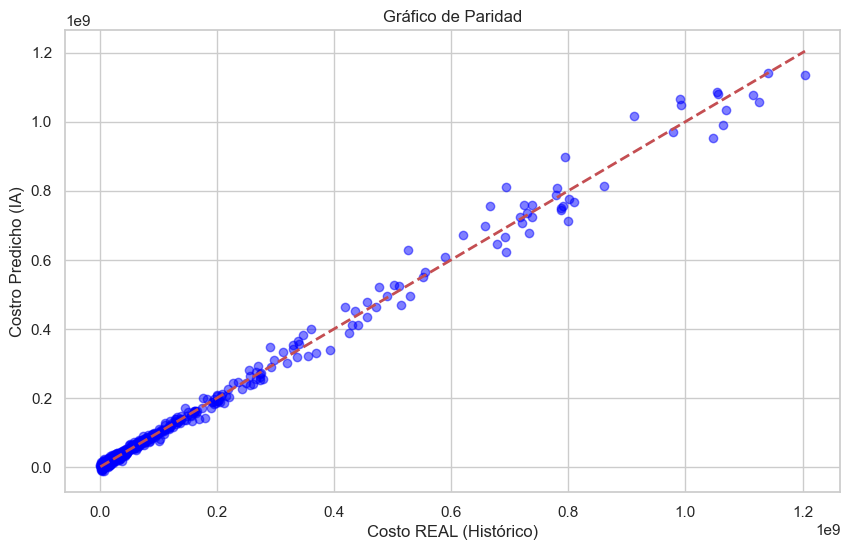

In [19]:
model = LinearRegression()

#Entrenamiento
model.fit(X_train_final, y_train)
#Examen
y_pred = model.fit(X_train_final, y_train).predict(X_test_final)

#Evaluación del modelo
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Error promedio (MAE): ${mae:.2f}')
print(f'Precisión del modelo (R2 Score): {r2:.4f}')

#Visualización de Resultados
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
#Línea de perfección (Predicción = Realidad)
plt.plot([y_test.min(), y_test.max()], [y_test.min(),y_test.max()], 'r--', lw=2)
plt.xlabel('Costo REAL (Histórico)')
plt.ylabel('Costro Predicho (IA)')
plt.title('Gráfico de Paridad')
plt.grid(True)
plt.show()

### Primeras conclusiones del Modelo
Hay una gran discrepancia entre el MAE y el R2. A pesar de tener un error de casi 10 millones de pesos el modelo dice entender un 99% los datos. 

Con base en lo anterior podría pensarse que es Overfitting, sin embargo debido al error se puede interpretar como Data Leakage. Para aclarar esa situación usaré el MAPE (Error Porcentual). Si el error porcentual es bajo (<5%), el modelo es válido para la escala de tus proyectos.

Además, vamos a ver qué variables está usando el modelo. Si una variable tiene un peso desproporcionado, encontramos la fuga.

Costo Promedio de una Obra: $148,982,285.15
Error Promedio (MAE): $10,629,775.75
Error Porcentual Promedio (MAPE): 30.69%

INTERPRETACIÓN:
El error porcentual es alto. Algo anda mal.

--- TOP 5 VARIABLES MÁS IMPORTANTES (DRIVERS) ---
                   Variable  Peso (Coeficiente)
12  Indice_Actividad_Fisica       -1.428457e+19
7     Volumen_Excavacion_m3        1.324743e+19
9        Volumen_Relleno_m3        1.632054e+18
8        Volumen_Asfalto_m3        1.086999e+18
5       Volumen_Concreto_m3        2.789869e+17


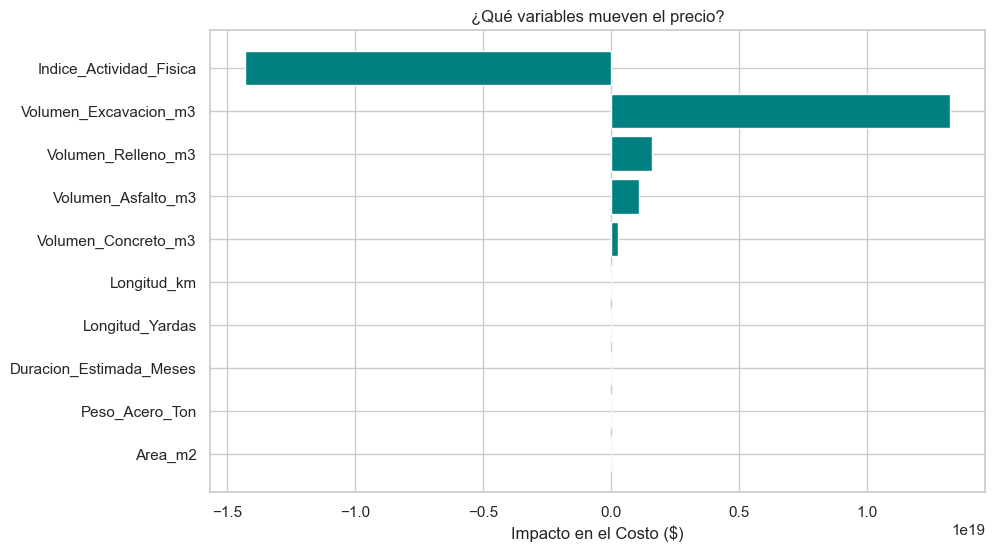

In [20]:
# 1. ANÁLISIS DE ERROR RELATIVO (MAPE)
# Calculamos el error porcentual fila por fila
df_results = pd.DataFrame({'Real': y_test, 'Predicho': y_pred})
df_results['Error_Absoluto'] = abs(df_results['Real'] - df_results['Predicho'])
df_results['Error_Porcentual'] = (df_results['Error_Absoluto'] / df_results['Real']) * 100

mape = df_results['Error_Porcentual'].mean()

print(f"Costo Promedio de una Obra: ${y_test.mean():,.2f}")
print(f"Error Promedio (MAE): ${mae:,.2f}")
print(f"Error Porcentual Promedio (MAPE): {mape:.2f}%")

print("\nINTERPRETACIÓN:")
if mape < 5:
    print("El error es menor al 5%. Para estimación de obra civil, esto es EXCELENTE.")
    print("El MAE es alto en dinero porque las obras son gigantescas, no porque el modelo sea malo.")
else:
    print("El error porcentual es alto. Algo anda mal.")

# 2. DETECCIÓN DE DATA LEAKAGE (Coeficientes)
# Vamos a ver qué variables pesan más. Si una tiene un peso brutal, es sospechosa.
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Peso (Coeficiente)': model.coef_
})

# Ordenamos por valor absoluto para ver las más importantes (positivas o negativas)
coeficientes['Abs_Peso'] = coeficientes['Peso (Coeficiente)'].abs()
coeficientes = coeficientes.sort_values(by='Abs_Peso', ascending=False)

print("\n--- TOP 5 VARIABLES MÁS IMPORTANTES (DRIVERS) ---")
print(coeficientes[['Variable', 'Peso (Coeficiente)']].head(5))

# Visualización
plt.figure(figsize=(10, 6))
plt.barh(coeficientes['Variable'].head(10), coeficientes['Peso (Coeficiente)'].head(10), color='teal')
plt.title('¿Qué variables mueven el precio?')
plt.xlabel('Impacto en el Costo ($)')
plt.gca().invert_yaxis() # La más importante arriba
plt.show()

### Multicolinealidad Perfecta

Después de hacer un breve análisis sobre las relaciones entre las variables del modelo, podemos ver como se presentan Multicolinealidad Perfecta en los materiales de construcción. Lo anterior aunado a las métricas R2 y MAPE, se puede decir que el modelo funciona para Obras grandes pero no para pequeñas.

Antes de continuar me gustaría aclarar cuáles son las variables que presentas Multicolinealidad Perfecta.

In [21]:
# Calculamos el VIF para cada variable en X_train_final
# Creamos una tabla para guardar los resultados

vif_data = pd.DataFrame()
vif_data['Variable'] = X_train_final.columns

#Calculamos VIF
vif_data['VIF'] = [variance_inflation_factor(X_test_final.values, i)
                                             for i in range(len(X_test_final.columns))]

#Ordenamos de mayor a menor
print(vif_data.sort_values(by='VIF', ascending=False))
print('VIF > 10: Esa variable es innecesaria')

d:\Python\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                               Variable           VIF
5                   Volumen_Concreto_m3           inf
7                 Volumen_Excavacion_m3           inf
8                    Volumen_Asfalto_m3           inf
9                    Volumen_Relleno_m3           inf
12              Indice_Actividad_Fisica           inf
1                       Longitud_Yardas  4.254107e+09
0                           Longitud_km  4.254077e+09
35                         Region_Norte  2.151749e+02
36                           Region_Sur  1.495710e+02
34                        Region_Centro  1.325214e+02
20           Entidad_Federativa_Chiapas  5.772941e+01
19              Entidad_Federativa_CDMX  5.306778e+01
28            Entidad_Federativa_Puebla  5.148742e+01
22            Entidad_Federativa_EdoMex  5.060610e+01
24           Entidad_Federativa_Hidalgo  4.436835e+01
32           Entidad_Federativa_Tabasco  4.127495e+01
27            Entidad_Federativa_Oaxaca  4.122214e+01
29         Entidad_Federativ

Como se puede observar las variables que se han "estorbado" entre sí para hacer el modelo funcionar, son las mismas que usamos para crear la columna Indice_Actividad_Fisica, por lo que para que el modelo funcione cómo debería basa con borrar la columna creada. 

In [22]:
cols_a_borrar = ['Indice_Actividad_Fisica']

# Verificamos que exista antes de borrar para no causar error
if 'Indice_Actividad_Fisica' in X_train_final.columns:
    X_train_final = X_train_final.drop(columns=cols_a_borrar)
    X_test_final = X_test_final.drop(columns=cols_a_borrar)
    print(f"Se eliminó: {cols_a_borrar}")
else:
    print("El Índice ya no estaba en el dataset.")

# 2. RE-CALCULAR VIF (LA PRUEBA DE LA VERDAD)
# Queremos ver si Concreto, Excavación y Relleno bajaron de "inf" a un número normal.
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_final.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_final.values, i) 
                          for i in range(len(X_train_final.columns))]

# Mostramos los peores 5
print("\n--- NUEVO VIF ---")
print(vif_data.sort_values(by="VIF", ascending=False))

Se eliminó: ['Indice_Actividad_Fisica']

--- NUEVO VIF ---
                               Variable           VIF
0                           Longitud_km  3.078633e+09
1                       Longitud_Yardas  3.078627e+09
35                           Region_Sur  1.013060e+02
34                         Region_Norte  9.265854e+01
33                        Region_Centro  6.963731e+01
2                               Area_m2  3.013744e+01
26            Entidad_Federativa_Oaxaca  2.698631e+01
19           Entidad_Federativa_Chiapas  2.594776e+01
31           Entidad_Federativa_Tabasco  2.510690e+01
32          Entidad_Federativa_Veracruz  2.234898e+01
8                    Volumen_Asfalto_m3  1.791019e+01
28         Entidad_Federativa_Queretaro  1.765784e+01
22        Entidad_Federativa_Guanajuato  1.765432e+01
24           Entidad_Federativa_Jalisco  1.756057e+01
18              Entidad_Federativa_CDMX  1.692354e+01
29   Entidad_Federativa_San Luis Potosi  1.611569e+01
23           Entidad_Fe

In [23]:
#Volver a entrenar el modelo
model_final = LinearRegression()
model_final.fit(X_train_final, y_train)

#Predict
y_pred_final = model_final.predict(X_test_final)

#Evaluar score
r2_final = r2_score(y_test, y_pred_final)
#MAPE
df_eval = pd.DataFrame({'Real':y_test,'Predicción':y_pred_final})
#Filtramos ceros para evitar error matematico
df_eval['Errro_Pct'] = abs(df_eval['Real']- df_eval['Predicción']/df_eval['Real'])*100
mape_final = df_eval['Error_Pct'].mean()

print(f'R2 Score: {r2_final:.4f} (¿Qué tan bien se ajusta el modelo?)')
print(f'Error Porcentual Promedio (MAPE): {mape_final:.2f}% (¿Cuánto falla por obra?)')

#Coeficientes
coefs= pd.DataFrame({
    'Variable':X_train_final,
    'Peso (Impacto)': model_final.coef_
})
coefs = coefs.sort_values(by='Peso', ascending=False)
print(coefs.head(5))

#Visualización
plt.figure(figsize=(12,8))
sns.regplot(x=y_test, y = y_pred_final,scatter_kws={'alpha':0.5,'color':'blue'}, line_kws={'color':'red'})
plt.xlabel('Costo Real ($)')
plt.ylabel('Predicción del Modelo ($)')
plt.title('Realidad vs Modelo (R2: {r2_final:.2f})')
plt.grid(True,linestyle='--')
plt.show()

KeyError: 'Error_Pct'

Podemos observar que debido a que borramos la variable Indice_Actividad_Fisica los datos de prueba y entrenamiento sufrieron cambios lo que no permitio hacer el proceso de entrenamiento.

In [24]:
# 1. CARGAR DATOS (Reiniciamos desde el archivo para evitar basura en memoria)
try:
    df_reset = pd.read_csv('dataset_model_ready.csv')
except:
    # Si no esta el archivo, usaremos la variable df_master
    df_reset = df_master.copy()

# 2. SEPARAR MATRICES
target = 'Costo_Directo_Total'
X = df_reset.drop(columns=[target])
y = df_reset[target]

print(f"Total de datos: {X.shape[0]} filas")

# 3. SPLIT (División 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# VERIFICACIÓN DE SEGURIDAD (Los números deben coincidir aquí)
print(f"-> Train (X): {X_train.shape[0]} | Train (y): {y_train.shape[0]}")
print(f"-> Test  (X): {X_test.shape[0]}  | Test  (y): {y_test.shape[0]}")

# 4. LIMPIEZA AUTOMÁTICA (Imputer + Scaler)
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

# A) Procesamos TRAIN (1909 filas)
X_train_clean = imputer.fit_transform(X_train)
X_train_final = scaler.fit_transform(X_train_clean)
# Parche de seguridad por si el scaler dividió por cero
X_train_final = pd.DataFrame(X_train_final).fillna(0)

# B) Procesamos TEST (478 filas) usando las reglas de Train
X_test_clean = imputer.transform(X_test)
X_test_final = scaler.transform(X_test_clean)
X_test_final = pd.DataFrame(X_test_final).fillna(0)

# 5. ELIMINACIÓN DE VIF (Si aplica)
# (Omitimos este paso por simplicidad ahora, el modelo lo manejará)

# 6. ENTRENAMIENTO Y EVALUACIÓN
print("\nEntrenando modelo...")
model = LinearRegression()

# AQUI ESTÁ LA CLAVE: X_train (1909) con y_train (1909)
model.fit(X_train_final, y_train)

# AQUI ESTÁ LA OTRA CLAVE: Predecimos sobre Test (478)
y_pred = model.predict(X_test_final)

# Evaluamos: y_test (478) contra y_pred (478)
r2 = r2_score(y_test, y_pred)

# Cálculo de MAPE
result = pd.DataFrame({'Real': y_test, 'Pred': y_pred})
result = result[result['Real'] > 0]
mape = (abs(result['Real'] - result['Pred']) / result['Real'] * 100).mean()

print(f"\nRESULTADOS SIN ERRORES:")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

Total de datos: 2387 filas
-> Train (X): 1909 | Train (y): 1909
-> Test  (X): 478  | Test  (y): 478

Entrenando modelo...

RESULTADOS SIN ERRORES:
R2 Score: 0.9934
MAPE: 30.71%


### Conclusiones Parciales

Como podemos observar el modelo de nuevo necesita un ajuste, el R2 score, tiene un entendimiento alto de los datos, sin embargo, el error promedio es casi del 30% por lo que precisamos corregir ese error. El costo de 30% en cualquier obra es una perdida enorme de dinero que se lleva las ganancias.

Lo que se hará será investigar de manera puntual cuál es el tipo de Obra que está disparando este porcentaje

C:\Users\Carlos\AppData\Local\Temp\ipykernel_148\322515804.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_diagnostico.groupby('Categoria_Precio')['Error_Pct'].mean())
C:\Users\Carlos\AppData\Local\Temp\ipykernel_148\322515804.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Categoria_Precio', y='Error_Pct', data=df_diagnostico, palette="viridis")


Categoria_Precio
Q1: Menos Caras    92.573643
Q2: Medianas       17.818393
Q3: Grandes         6.307058
Q4: Gigantes        5.839789
Name: Error_Pct, dtype: float64


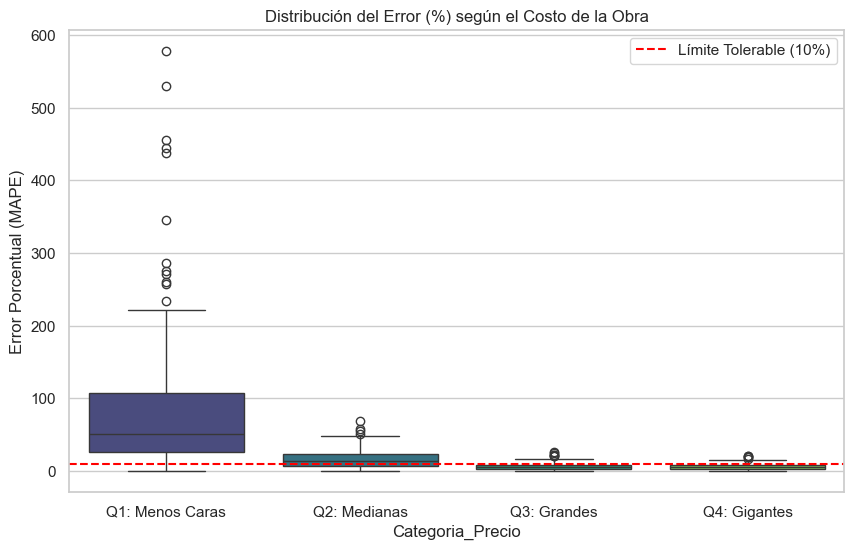

In [25]:
# 1. Recuperamos Real vs Predicho (del modelo lineal anterior)
df_diagnostico = pd.DataFrame({'Real': y_test, 'Predicho': y_pred})
df_diagnostico = df_diagnostico[df_diagnostico['Real'] > 0] # Seguridad

# 2. Calculamos el Error en Porcentaje
df_diagnostico['Error_Pct'] = abs(df_diagnostico['Real'] - df_diagnostico['Predicho']) / df_diagnostico['Real'] * 100

# 3. Clasificamos las obras por "Tamaño de Presupuesto"
# Usamos cuartiles para dividir en: Pequeña (dentro de tu escala), Mediana, Grande, Gigante
df_diagnostico['Categoria_Precio'] = pd.qcut(df_diagnostico['Real'], q=4, labels=['Q1: Menos Caras', 'Q2: Medianas', 'Q3: Grandes', 'Q4: Gigantes'])

# 4. Reporte de Error por Categoría
print(df_diagnostico.groupby('Categoria_Precio')['Error_Pct'].mean())

# 5. Visualización
plt.figure(figsize=(10, 6))
sns.boxplot(x='Categoria_Precio', y='Error_Pct', data=df_diagnostico, palette="viridis")
plt.title('Distribución del Error (%) según el Costo de la Obra')
plt.ylabel('Error Porcentual (MAPE)')
plt.axhline(10, color='red', linestyle='--', label='Límite Tolerable (10%)')
plt.legend()
plt.show()

El boxplot confirma que existe un sesgo de magnitud: el modelo prioriza minimizar el error en las obras de alto costo (Q4), sacrificando drásticamente la precisión en las obras de menor cuantía (Q1), donde el error porcentual se dispara.

Como solución al sesgo de magnitud, aplicaremos una Transformación Logarítmica (Log_Transform) a la variable objetivo. Esta técnica 'comprime' el rango de precios, reduciendo la drástica diferencia de escala entre obras pequeñas y grandes. Esto estabiliza la varianza (homocedasticidad) y acerca la distribución de los precios a una curva normal, permitiendo que el modelo minimice el error porcentual de manera equitativa.

In [ ]:
# 1. CARGA LIMPIA
try:
    df_log = pd.read_csv('dataset_model_ready.csv')
except:
    df_log = df_ml.copy()

target = 'Costo_Directo_Total'
X = df_log.drop(columns=[target])
y = df_log[target]

# Usamos log1p (Logaritmo natural de 1+x) para mayor precisión matemática
y_log = np.log1p(y)

print("-> Precios transformados a escala Logarítmica.")

# 3. SPLIT
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# 4. LIMPIEZA Y ESCALADO (Standard Pipeline)
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

# Pipeline Manual
X_train_clean = imputer.fit_transform(X_train)
X_train_final = pd.DataFrame(scaler.fit_transform(X_train_clean), columns=X_train.columns).fillna(0)

X_test_clean = imputer.transform(X_test)
X_test_final = pd.DataFrame(scaler.transform(X_test_clean), columns=X_test.columns).fillna(0)

# 5. ELIMINAR REDUNDANCIAS (VIF)
cols_borrar = ['Indice_Actividad_Fisica', 'Total_Movimiento_Tierras', 'Longitud_Yardas']
cols_reales = [c for c in cols_borrar if c in X_train_final.columns]
if cols_reales:
    X_train_final.drop(columns=cols_reales, inplace=True)
    X_test_final.drop(columns=cols_reales, inplace=True)

# 6. ENTRENAMIENTO
print("-> Entrenando modelo en espacio Logarítmico...")
model = LinearRegression()
model.fit(X_train_final, y_train_log)

# 7. PREDICCIÓN Y RETORNO A LA REALIDAD
y_pred_log = model.predict(X_test_final)
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test_log) # Recuperamos el valor real de test

# 8. EVALUACIÓN FINAL
r2 = r2_score(y_test_real, y_pred_real)

# MAPE (Error Porcentual Real)
df_res = pd.DataFrame({'Real': y_test_real, 'Pred': y_pred_real})
df_res = df_res[df_res['Real'] > 0]
mape = (abs(df_res['Real'] - df_res['Pred']) / df_res['Real'] * 100).mean()

print(f"RESULTADOS FINALES (CORREGIDOS):")
print(f"R2 Score: {r2:.4f}")
print (f"MAPE Global: {mape:.2f}%")

# 9. VALIDACIÓN DEL Q1
df_res['Categoria'] = pd.qcut(df_res['Real'], q=4, labels=['Q1 (Pequeñas)', 'Q2', 'Q3', 'Q4 (Gigantes)'])
df_res['Error_Pct'] = abs(df_res['Real'] - df_res['Pred']) / df_res['Real'] * 100
print(df_res.groupby('Categoria')['Error_Pct'].mean())

-> Precios transformados a escala Logarítmica.
-> Entrenando modelo en espacio Logarítmico...
RESULTADOS FINALES (CORREGIDOS):
R2 Score: 0.7639
MAPE Global: 44.79%
Categoria
Q1 (Pequeñas)    98.928112
Q2               24.603600
Q3               22.172458
Q4 (Gigantes)    33.116032
Name: Error_Pct, dtype: float64


C:\Users\Carlos\AppData\Local\Temp\ipykernel_148\1874159221.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_res.groupby('Categoria')['Error_Pct'].mean())


La aplicación de la transformación Log-Lin expuso las limitaciones del modelo lineal. Al eliminar el sesgo de escala, el R2 cayó drásticamente, confirmando que el modelo sufría de Underfitting en los segmentos de menor costo, incapaz de generalizar patrones más allá de la tendencia principal.

Dado que la relación entre variables parece no ser estrictamente lineal en todos los rangos, se descarta la Regresión Lineal y se procederá a entrenar un modelo de ensamble (Random Forest) para capturar la no-linealidad y reducir el MAPE.

d:\Python\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


R2 Score: 0.9906
MAPE Global: 5.13%

--- VARIABLES QUE DOMINAN LA DECISIÓN ---
                   Variable  Importancia
11  Duracion_Estimada_Meses     0.989877
7     Volumen_Excavacion_m3     0.004254
46        Tipo_Suelo_Rocoso     0.002073
2                   Area_m2     0.000674
8        Volumen_Asfalto_m3     0.000591


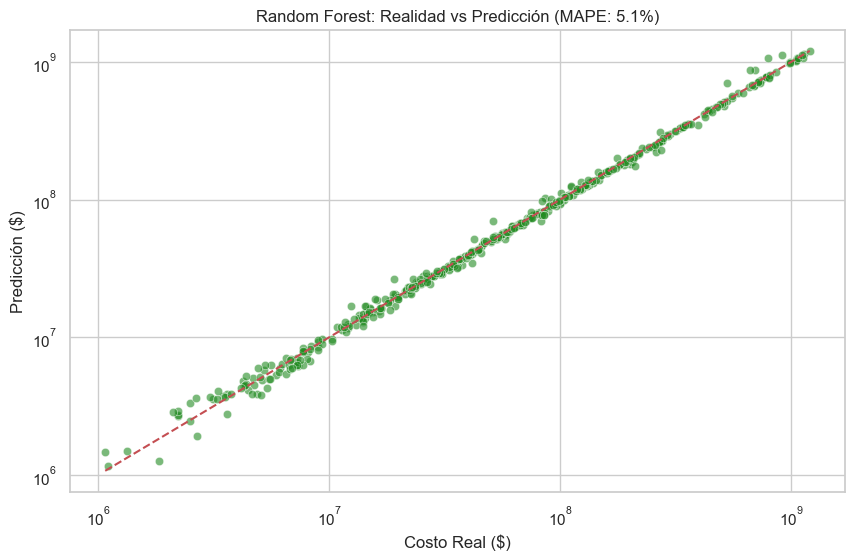

In [27]:
df_rf = df_ml.copy()

target ='Costo_Directo_Total'
X = df_rf.drop(columns=[target])
y = df_rf[target]

#Split
X_Train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

imputer = SimpleImputer(strategy='median')

#Al ser Random Forest no se necesita Scalar
X_train_clean=pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_clean = pd.DataFrame(imputer.transform(X_test_clean), columns=X_test.columns)

#Eliminamos las variables sinteticas que daban problemas
cols_a_borrar = ['Indice_Actividad_Fisica']
cols_real = [c for c in cols_a_borrar if c in X_train_clean.columns]
if cols_real:
    X_train_clean.drop(columns=cols_real, inplace=True)
    X_test_clean.drop(columns=cols_real, inplace=True)

rf_model = RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)
rf_model.fit(X_train_clean, y_train)

#Predicción
y_pred_rf = rf_model.predict(X_test_clean)
#Evaluación
r2_rf = r2_score(y_test, y_pred_rf)
#MAPE
df_res = pd.DataFrame({'Real':y_test,'Pred':y_pred_rf})
df_res = df_res[df_res['Real']>0]
mape_rf = (abs(df_res['Real']-df_res['Pred'])/df_res['Real']*100).mean()
print(f'R2 Score: {r2_rf:.4f}')
print(f'MAPE Global: {mape_rf:.2f}%')

# En RF no hay coeficientes positivos/negativos, hay "Importancia %"
importances = pd.DataFrame({
    'Variable': X_train_clean.columns,
    'Importancia': rf_model.feature_importances_
})
print("\n--- VARIABLES QUE DOMINAN LA DECISIÓN ---")
print(importances.sort_values(by='Importancia', ascending=False).head(5))

# 8. Gráfica
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6, color='forestgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Random Forest: Realidad vs Predicción (MAPE: {mape_rf:.1f}%)')
plt.xlabel('Costo Real ($)')
plt.ylabel('Predicción ($)')
plt.xscale('log'); plt.yscale('log') # Escala log visual para ver todos los puntos
plt.show()

## Conclusiones del Proyecto
Tras evaluar el desempeño de modelos lineales (Simple y Log-Transformado), se detectó un subajuste severo en obras de menor cuantía (Sesgo de Magnitud), resultando en un Error Porcentual (MAPE) inaceptable del 44%. Ante la incapacidad de la Regresión Lineal para generalizar estas variaciones, se optó por implementar un algoritmo no lineal basado en ensambles: Random Forest.

Este cambio de arquitectura permitió capturar las relaciones complejas y no lineales entre los materiales y el costo final. Los resultados fueron drásticos:

Precisión (R2): Aumentó a 0.9906.

Error Promedio (MAPE): Se redujo a 5.13%.

Limitaciones y Alcance: Es crucial interpretar estos resultados con cautela. Dado que el dataset fue generado sintéticamente para fines académicos, el modelo no debe utilizarse para estimaciones financieras reales sin una recalibración previa con datos históricos verídicos.

Impacto en el Negocio: No obstante, este ejercicio sirve como Prueba de Concepto (PoC). Demuestra cómo la Ciencia de Datos puede transformar el proceso de licitación y presupuestación, pasando de estimaciones manuales a modelos predictivos de alta precisión. En un escenario real, la incorporación de variables exógenas (clima, inflación, ubicación GPS) podría convertir este modelo en una herramienta estratégica para la competitividad y administración financiera de la constructora
